# Cached Prediction EDA

Streamlined analysis notebook for cached LORO outputs with all-genes model fits in harmonized evaluation space.

In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.results_eda import *


In [2]:
import importlib
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)

<module 'src.eval_utils.results_eda' from '/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py'>

In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',  # or 'out/loro_subject_cache_arxiv'
    gene_scope='allgenes',
    plam_cache_dirname='plam',
)
CFG
print('analysis scope:', CFG.gene_scope)

analysis scope: allgenes


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 318
genes: 13618
parcels: 150


In [5]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(12)


n (subjects in pool) = 318; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,10,LH-Ca,caudate (basal ganglia),279,279,LH-Ca: caudate (basal ganglia)
1,18,LH-NAC,nucleus accumbens (basal ganglia),273,273,LH-NAC: nucleus accumbens (basal ganglia)
2,5,Cerebellar_Region5,cerebellar hemisphere,262,262,Cerebellar_Region5: cerebellar hemisphere
3,38,LH_Default_PFC_5,frontal cortex (ba9),252,252,LH_Default_PFC_5: frontal cortex (ba9)
4,0,Cerebellar_Region1,cerebellum,251,251,Cerebellar_Region1: cerebellum
5,19,LH-Pu,putamen (basal ganglia),250,250,LH-Pu: putamen (basal ganglia)
6,16,LH-HTH,hypothalamus,242,242,LH-HTH: hypothalamus
7,31,LH_Cont_PFCl_1,cortex,240,240,LH_Cont_PFCl_1: cortex
8,55,LH_Hippocampus,hippocampus,240,240,LH_Hippocampus: hippocampus
9,132,RH_SalVentAttn_Med_2,anterior cingulate cortex (ba24),223,223,RH_SalVentAttn_Med_2: anterior cingulate corte...


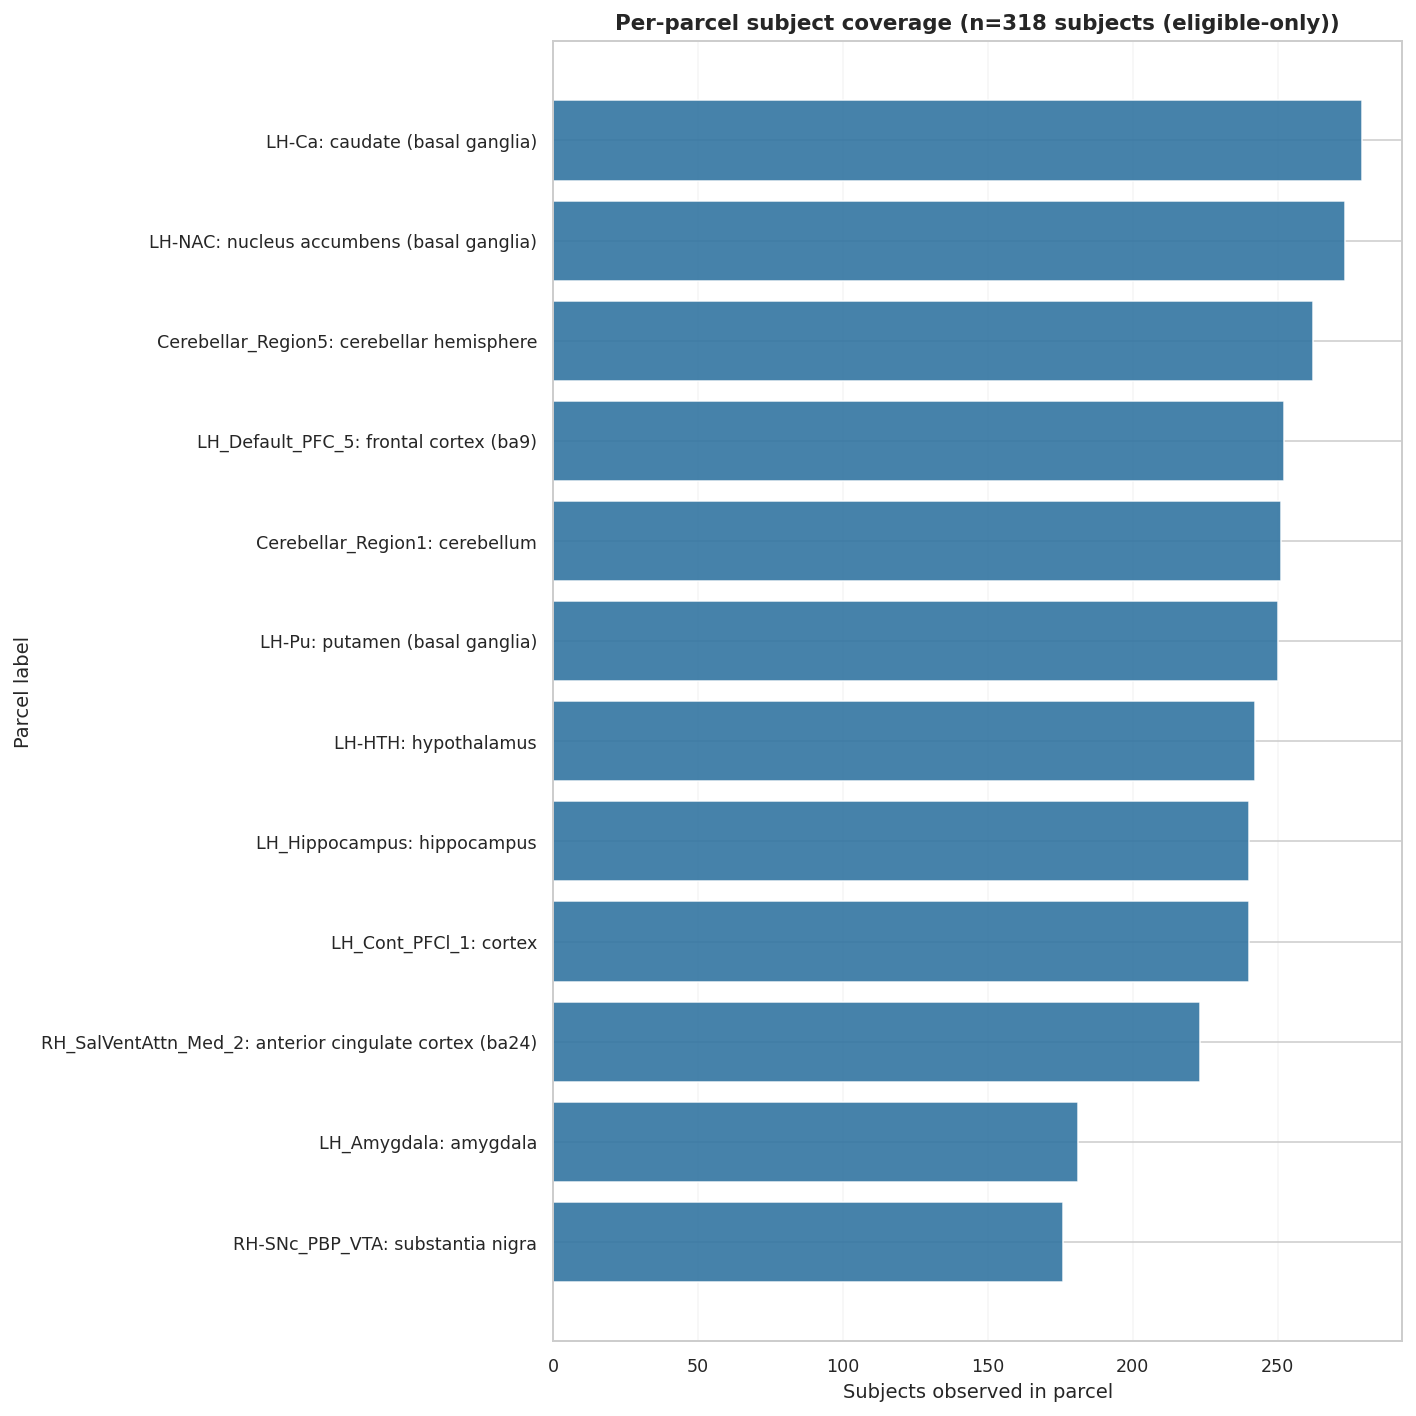

In [6]:
fig_h = max(8.0, 0.20 * len(count_df))
fig, ax = plot_parcel_subject_counts(count_df, top_n=None, min_subjects=1, figsize=(10, 10))


,n_regions_sampled,n_subjects,eligible_only,n_subjects_pool
0,5,21,True,318
1,6,29,True,318
2,7,36,True,318
3,8,29,True,318
4,9,53,True,318
5,10,54,True,318
6,11,63,True,318
7,12,33,True,318


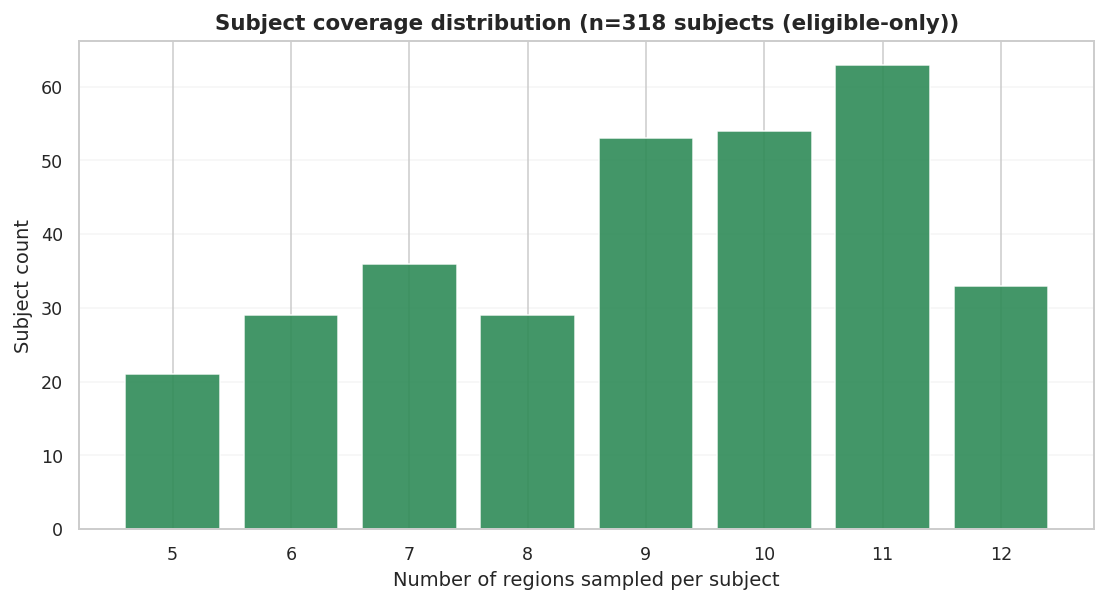

In [7]:
# LORO-relevant: x=regions sampled per subject, y=subject count
subj_cov = subject_region_count_distribution(PREPOST, eligible_only=ELIGIBLE_ONLY)
display(subj_cov)
fig, ax = plot_subject_region_count_distribution(subj_cov)


In [8]:
CSV_PATH = "data/raw/gxp_samples.csv"
gxp_samples_df = pd.read_csv(CSV_PATH)


/tmp/ipykernel_4002564/4168357976.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gxp_samples_df = pd.read_csv(CSV_PATH)


In [9]:
from data.utils import (
    build_and_write_hvg_gene_list,
    build_and_write_tissue_deg_gene_list,
)

# GTEx HVGs: default tissue-discriminative
out_path, ranked = build_and_write_hvg_gene_list(
    samples_df=gxp_samples_df,
    dataset="GTEx",
    method="variance",
    n_genes=100,
)
print("wrote", out_path)

# GTEx HVGs: within-tissue / demeaned alternative
out_path, ranked = build_and_write_hvg_gene_list(
    samples_df=gxp_samples_df,
    dataset="GTEx",
    method="demeaned",
    n_genes=100,
    out_name=f"gtex_100hvg_demeaned.txt",
)
print("wrote", out_path)

# GTEx tissue-enriched DEG panel: top 10 per tissue
deg_path, deg_ranked = build_and_write_tissue_deg_gene_list(
    samples_df=gxp_samples_df,
    dataset="GTEx",
    top_k_per_group=25,
    out_name="gtex_25deg.txt",
)
print("wrote", deg_path)
display(deg_ranked.head(24))


wrote /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/data/raw/gtex_100hvg.txt
wrote /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/data/raw/gtex_100hvg_demeaned.txt
wrote /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/data/raw/gtex_25deg.txt


,group,gene,dataset,mean_in,mean_out,log_fc,rank_within_group
0,brain - amygdala,KLK7,GTEX,3.011872,1.207531,1.804341,1
1,brain - amygdala,CCK,GTEX,4.930755,3.149669,1.781086,2
2,brain - amygdala,SLC17A7,GTEX,5.339869,3.685006,1.654863,3
3,brain - amygdala,DDN,GTEX,5.253020,3.725836,1.527184,4
4,brain - amygdala,SLC30A3,GTEX,2.517288,1.219440,1.297848,5
5,brain - amygdala,LHX2,GTEX,3.711220,2.568119,1.143101,6
6,brain - amygdala,CAMK2A,GTEX,5.335330,4.192620,1.142710,7
7,brain - amygdala,RPRM,GTEX,2.897282,1.760836,1.136447,8
8,brain - amygdala,MEIS3,GTEX,3.836425,2.727564,1.108861,9
9,brain - amygdala,LY6H,GTEX,5.295095,4.195659,1.099436,10


## 2) Pre/Post ComBat Diagnostics


In [10]:
# gene_mode: 'hvg' | 'allgenes' | 'custom'
GENE_MODE = 'hvg'
CUSTOM_GENE_LIST = None

atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 12
genes in panel: 88


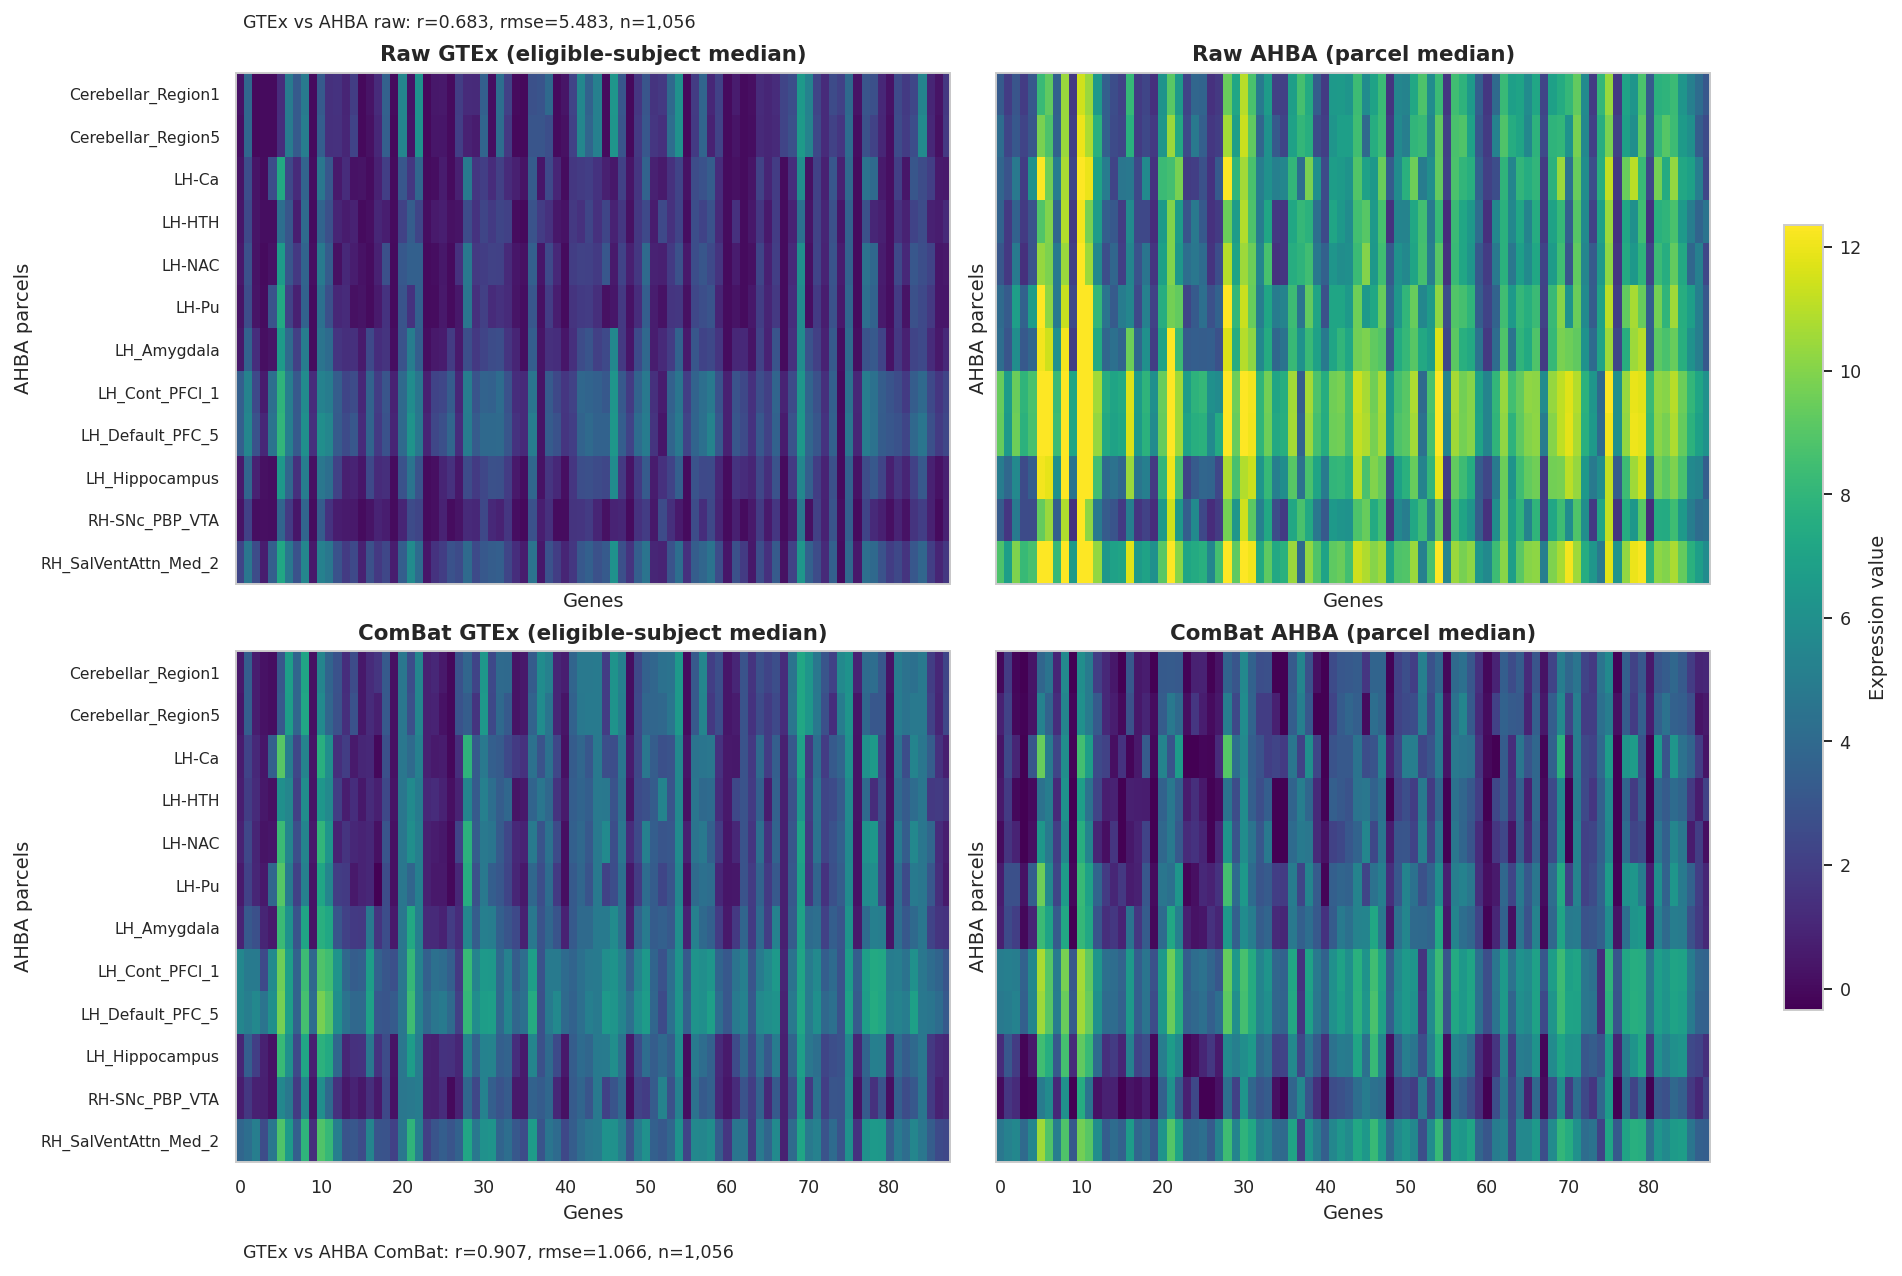

In [11]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


subject: GTEX-1117F


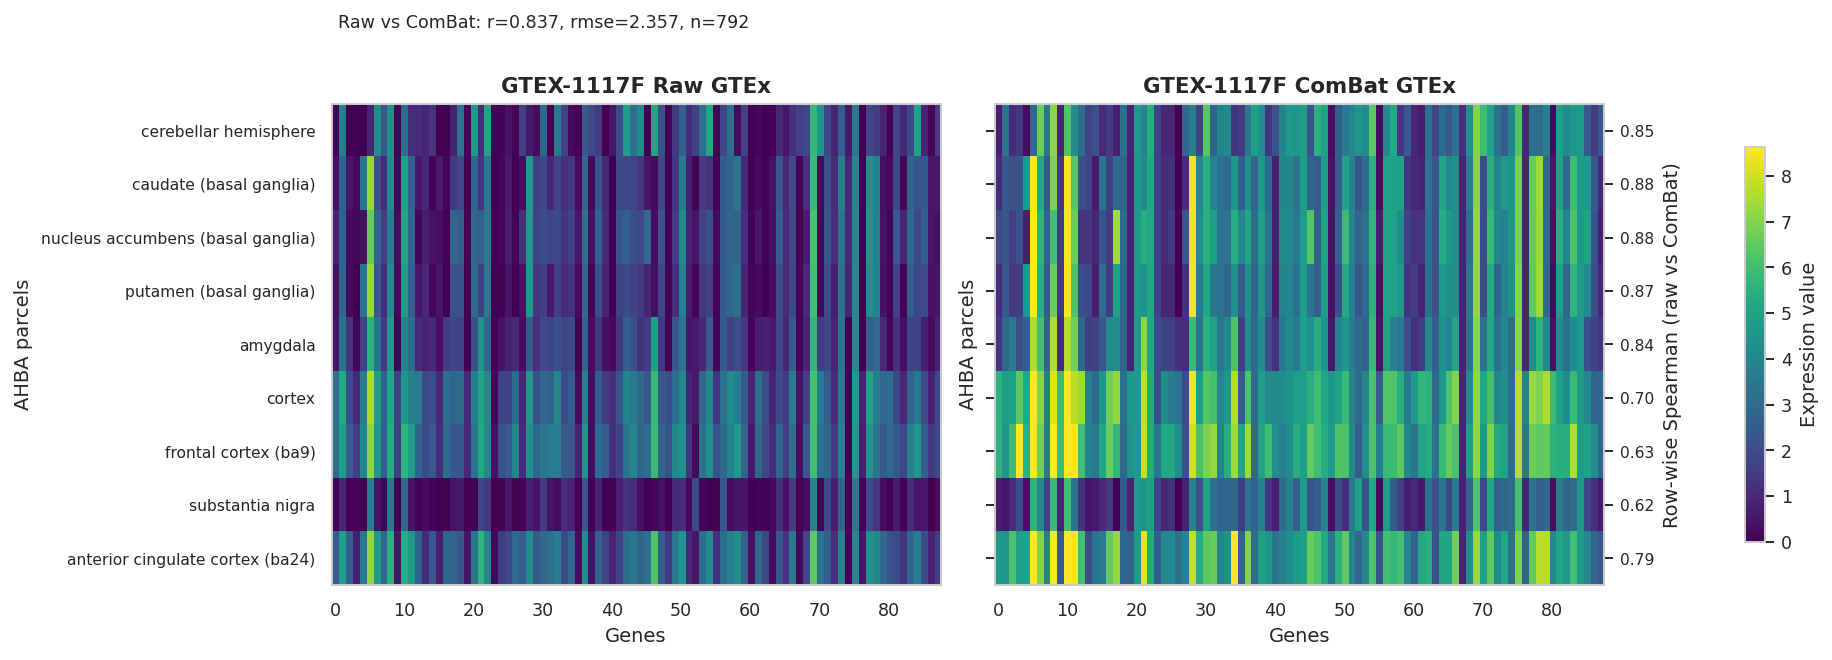

In [12]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


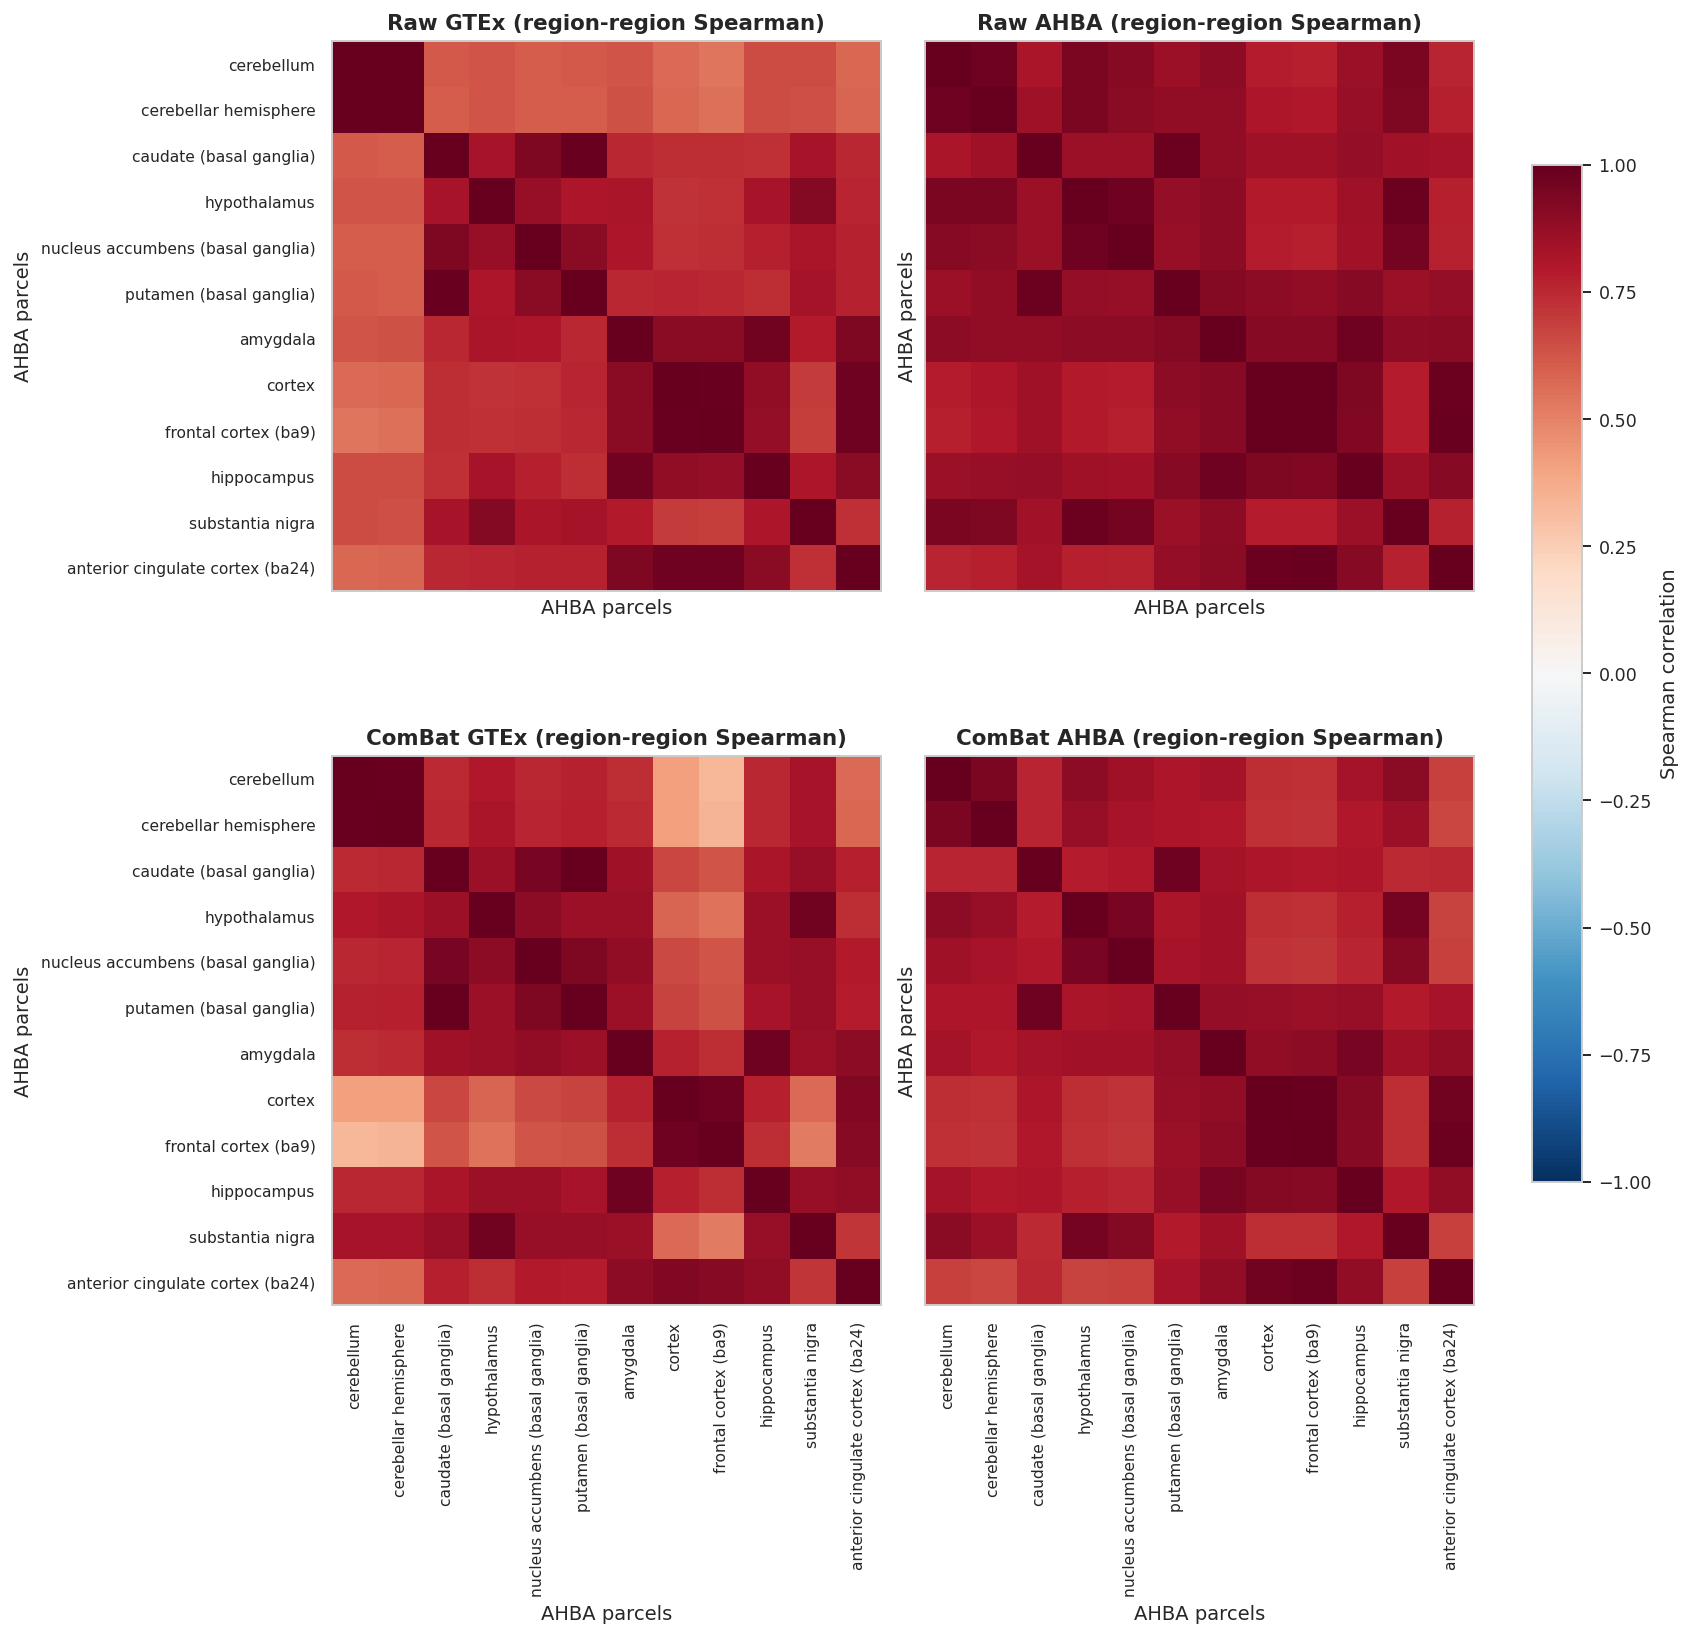

In [13]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


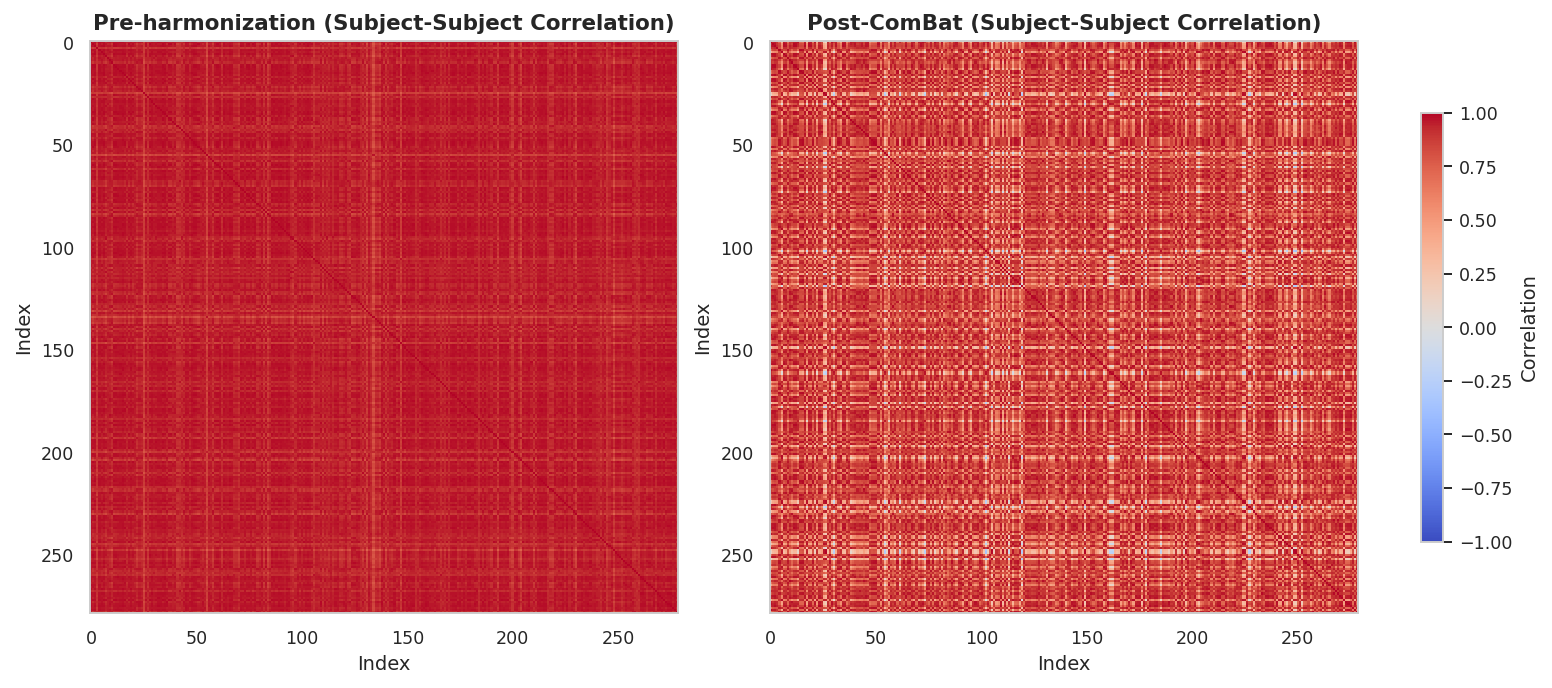

In [14]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')


## 3) Performance across Gene Panels


In [15]:
import importlib
import src.eval_utils.results_eda as results_eda
importlib.reload(results_eda)
from src.eval_utils.results_eda import *

from scipy.stats import ttest_rel
from itertools import combinations

MODELS = ['naive', 'dlam', 'plam']
N_JOBS = 16


def paired_ttests_by_subject(metrics_df, label=''):
    pivot = metrics_df.pivot(index='subject', columns='model', values='pearson_r').dropna()
    model_names = pivot.columns.tolist()
    t_results = {}
    print(f"\nPaired t-tests for {label}:")
    for model1, model2 in combinations(model_names, 2):
        t_stat, p_val = ttest_rel(pivot[model1], pivot[model2])
        t_results[(model1, model2)] = {'t_stat': t_stat, 'p_val': p_val}
        print(f"  {model1} vs {model2}: t = {t_stat:.4f}, p = {p_val:.4g}")
    return pivot, t_results


def run_subject_metric_panel(label, eval_gene_path=None):
    dfs = [
        compute_subject_metrics_from_cache_gene_subset(
            CFG,
            model=model,
            eval_gene_path=eval_gene_path,
            n_jobs=N_JOBS,
        )
        for model in MODELS
    ]
    metrics_df = pd.concat(dfs, ignore_index=True)
    display(metrics_df.head())
    fig, axes, summary_df = plot_loro_subject_summary_bars(metrics_df, use_sem=True)
    display(summary_df)
    pivot_df, t_results = paired_ttests_by_subject(metrics_df, label=label)
    display(pivot_df.head())
    return metrics_df, summary_df, pivot_df, t_results

### All gene performance



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,13618,13618,all,None,None,68090,0.830004,0.869096,0.574283,1.127193
1,GTEX-131XW,naive,5,5,13618,13618,all,None,None,68090,0.853913,0.865389,0.554455,1.096063
2,GTEX-13NZA,naive,5,5,13618,13618,all,None,None,68090,0.822294,0.862225,0.514961,1.213825
3,GTEX-1477Z,naive,5,5,13618,13618,all,None,None,68090,0.823854,0.858986,0.535809,1.187866
4,GTEX-17MF6,naive,5,5,13618,13618,all,None,None,68090,0.821546,0.857661,0.516642,1.223745


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.848140,0.022141,0.886744,0.018366,0.603218,0.054006,1.057406,0.100871,313,0.001251,0.001038,0.003053,0.005702
1,dlam,0.870626,0.097145,0.903374,0.054453,0.548557,0.760910,0.963615,0.577354,313,0.005491,0.003078,0.043009,0.032634
2,plam,0.865123,0.076576,0.887865,0.049004,0.697995,0.236762,0.878047,0.276645,313,0.004328,0.002770,0.013383,0.015637



Paired t-tests for all genes:
  dlam vs naive: t = 3.9428, p = 9.95e-05
  dlam vs plam: t = 3.5520, p = 0.0004413
  naive vs plam: t = -3.7482, p = 0.0002122


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.883132,0.886137,0.875760
GTEX-111FC,0.886696,0.846861,0.873026
GTEX-117XS,0.886923,0.851439,0.875711
GTEX-1192W,0.879600,0.830004,0.853585
GTEX-1192X,0.944760,0.843251,0.927970


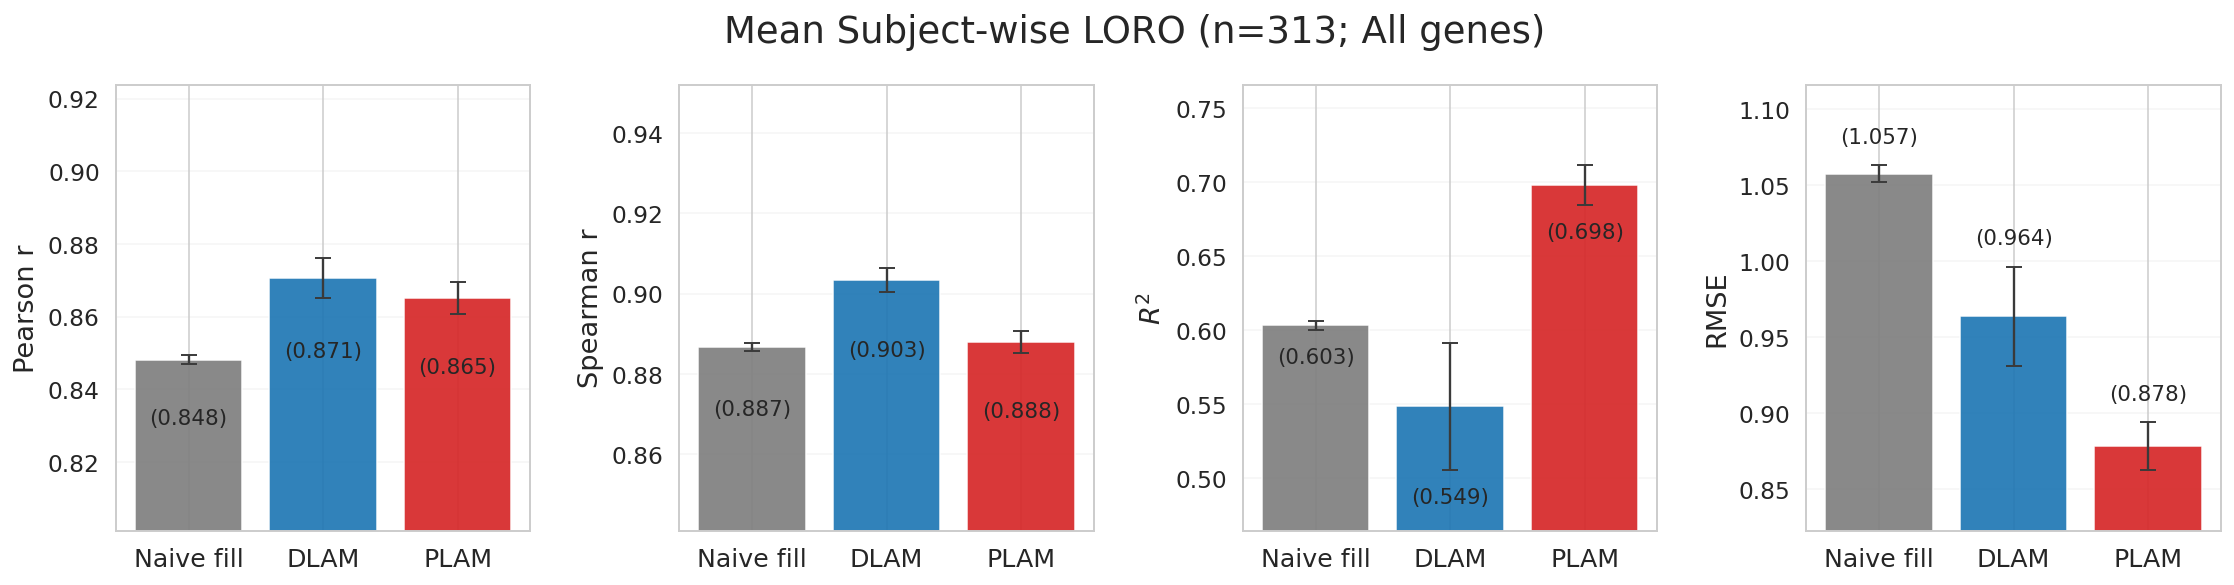

In [16]:
metrics_allgenes_eval, summary_allgenes_eval, pivot_allgenes, t_results_allgenes = run_subject_metric_panel(
    label='all genes',
)

### AHBA 100 HVG



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,440,0.840372,0.824144,0.476551,1.550226
1,GTEX-131XW,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,440,0.856050,0.846093,0.383814,1.574207
2,GTEX-13NZA,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,440,0.787870,0.786520,0.235200,1.799255
3,GTEX-1477Z,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,440,0.788748,0.774662,-0.173995,2.117086
4,GTEX-17MF6,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,440,0.809258,0.810121,0.035592,1.960707


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.854977,0.033215,0.846948,0.031909,0.607480,0.198020,1.348905,0.214844,313,0.001877,0.001804,0.011193,0.012144
1,dlam,0.772304,0.096060,0.770850,0.095345,0.424202,0.429358,1.622158,0.536334,313,0.005430,0.005389,0.024269,0.030315
2,plam,0.822537,0.045378,0.815982,0.043029,0.583585,0.201222,1.407340,0.305233,313,0.002565,0.002432,0.011374,0.017253



Paired t-tests for ahba_100hvg:
  dlam vs naive: t = -14.0140, p = 6.026e-35
  dlam vs plam: t = -9.8129, p = 5.501e-20
  naive vs plam: t = 15.3406, p = 5.713e-40


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.670338,0.874235,0.878290
GTEX-111FC,0.700391,0.888942,0.871896
GTEX-117XS,0.723931,0.884988,0.841299
GTEX-1192W,0.699868,0.840372,0.828332
GTEX-1192X,0.756564,0.870192,0.854012


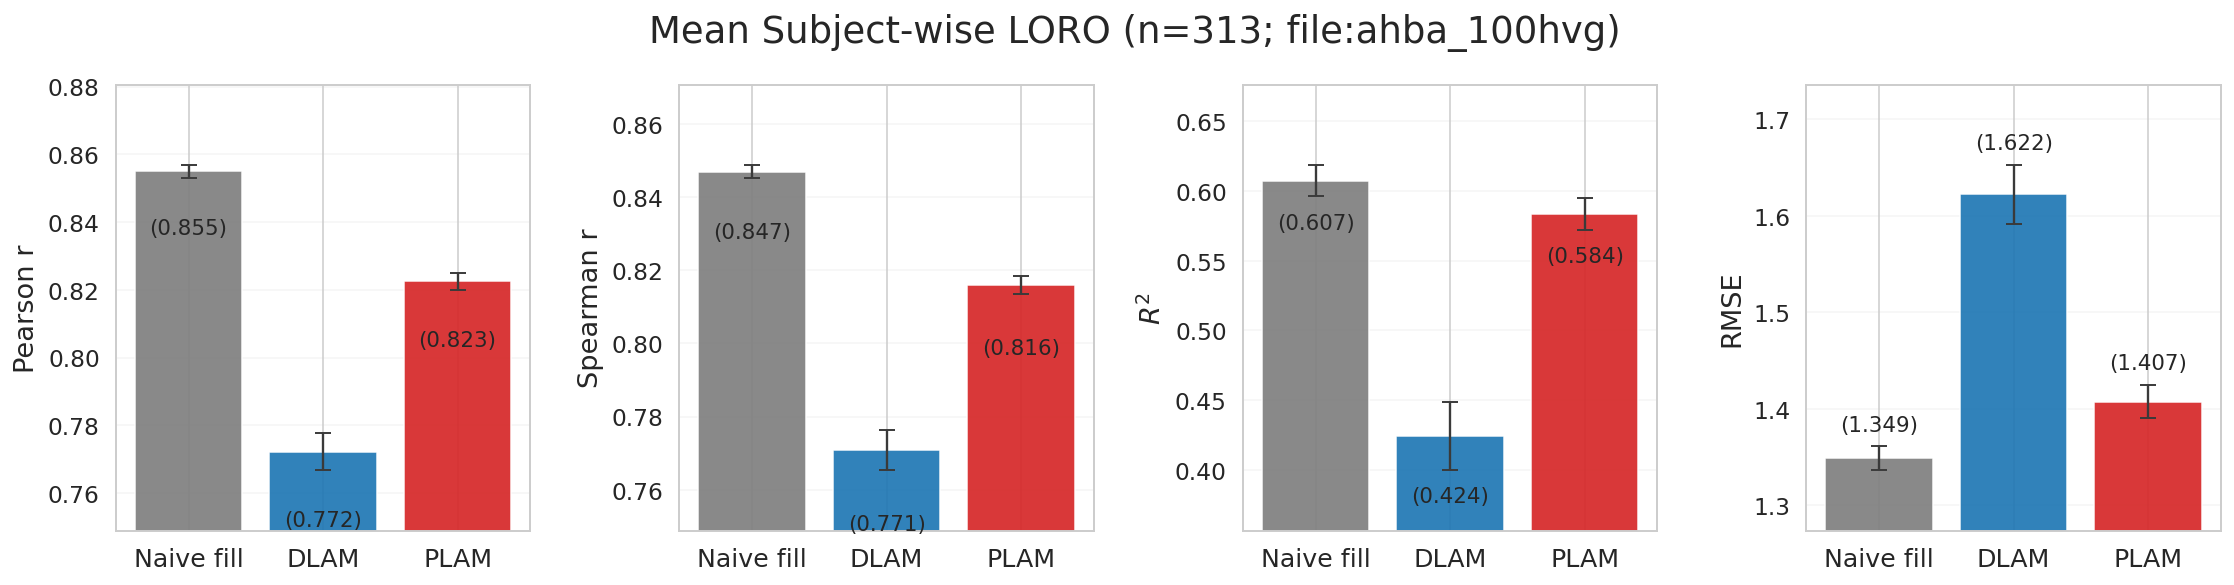

In [17]:
metrics_ahba100hvg_eval, summary_ahba100hvg_eval, pivot_ahba100hvg, t_results_ahba100hvg = run_subject_metric_panel(
    label='ahba_100hvg',
    eval_gene_path='ahba_100hvg',
)

### GTEx 100 HVG



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,500,0.669923,0.695916,-0.022032,1.818935
1,GTEX-131XW,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,500,0.788834,0.778436,0.279933,1.500597
2,GTEX-13NZA,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,500,0.642264,0.655319,-0.037272,1.919018
3,GTEX-1477Z,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,500,0.681198,0.689018,-0.079056,1.876219
4,GTEX-17MF6,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,500,0.692093,0.693223,0.005053,1.878024


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.747976,0.046863,0.759575,0.034002,0.374875,0.164235,1.554394,0.170577,313,0.002649,0.001922,0.009283,0.009642
1,dlam,0.798199,0.065166,0.792869,0.064074,0.603374,0.134743,1.233432,0.216113,313,0.003683,0.003622,0.007616,0.012215
2,plam,0.804900,0.029354,0.791179,0.028078,0.608907,0.062799,1.237360,0.100492,313,0.001659,0.001587,0.003550,0.005680



Paired t-tests for gtex_100hvg:
  dlam vs naive: t = 10.5994, p = 1.268e-22
  dlam vs plam: t = -1.9414, p = 0.05311
  naive vs plam: t = -18.8811, p = 1.454e-53


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.761655,0.761566,0.851141
GTEX-111FC,0.791432,0.748239,0.829110
GTEX-117XS,0.754016,0.790563,0.832244
GTEX-1192W,0.780277,0.669923,0.810441
GTEX-1192X,0.772192,0.790326,0.816241


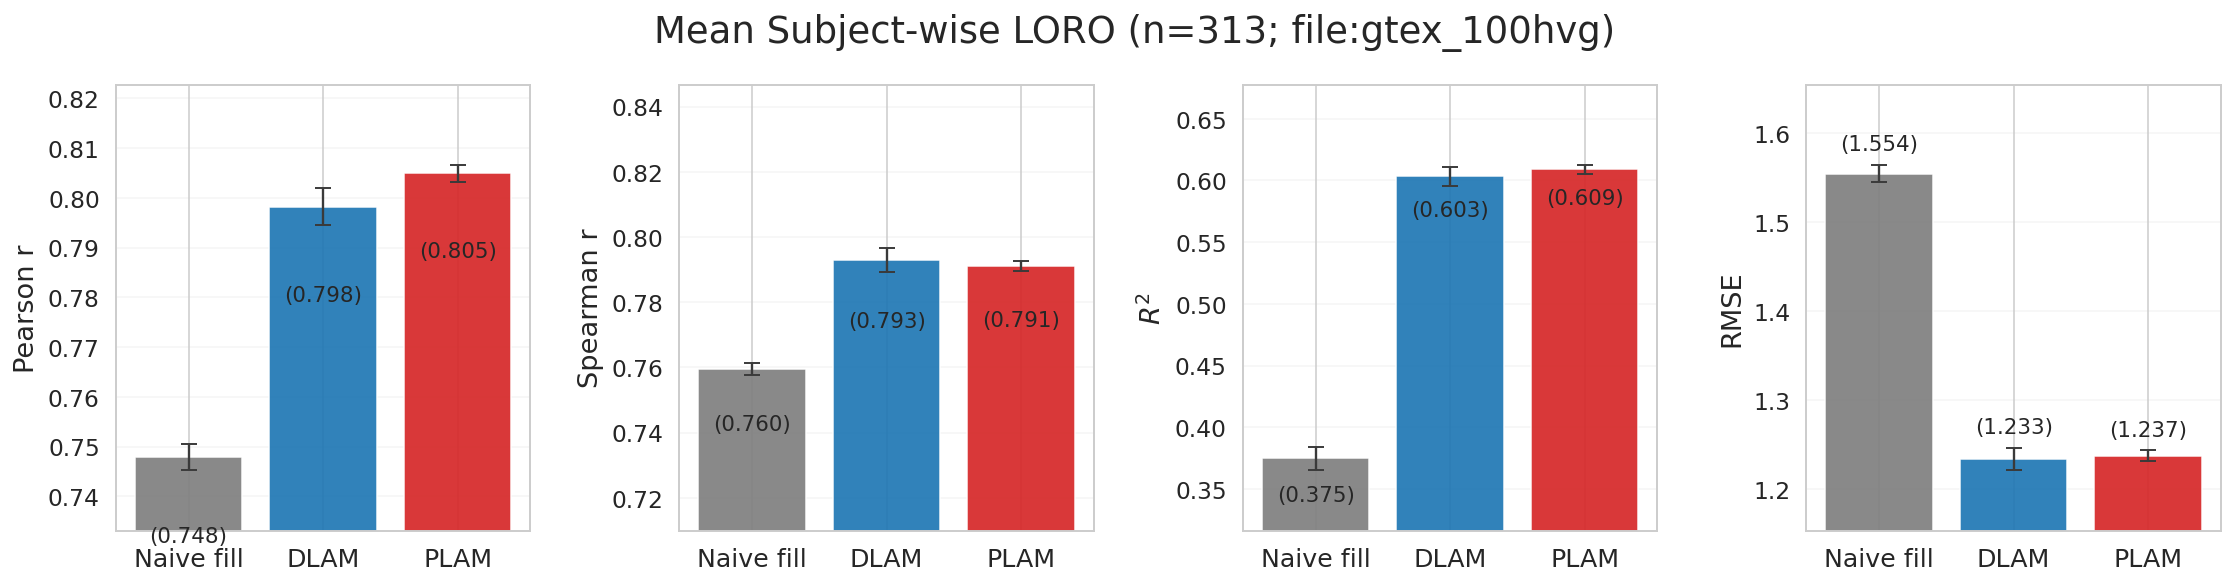

In [18]:
metrics_gtex100hvg_eval, summary_gtex100hvg_eval, pivot_gtex100hvg, t_results_gtex100hvg = run_subject_metric_panel(
    label='gtex_100hvg',
    eval_gene_path='gtex_100hvg',
)

### GTEx 120 DEG



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,845,0.764921,0.759812,0.230966,1.563156
1,GTEX-131XW,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,845,0.842071,0.818170,0.442826,1.356569
2,GTEX-13NZA,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,845,0.780226,0.771799,0.314914,1.599826
3,GTEX-1477Z,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,845,0.784744,0.771234,0.298306,1.577302
4,GTEX-17MF6,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,845,0.796597,0.793633,0.353728,1.569665


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.832590,0.026373,0.818609,0.026751,0.545979,0.127617,1.312429,0.145511,313,0.001491,0.001512,0.007213,0.008225
1,dlam,0.792741,0.063143,0.793319,0.059871,0.583076,0.145749,1.255834,0.226409,313,0.003569,0.003384,0.008238,0.012797
2,plam,0.828335,0.024230,0.823035,0.024248,0.653142,0.066722,1.156247,0.118119,313,0.001370,0.001371,0.003771,0.006677



Paired t-tests for gtex_25deg:
  dlam vs naive: t = -10.6376, p = 9.387e-23
  dlam vs plam: t = -11.4799, p = 1.105e-25
  naive vs plam: t = 2.2633, p = 0.0243


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.738983,0.832467,0.851537
GTEX-111FC,0.760009,0.840195,0.837897
GTEX-117XS,0.739004,0.843519,0.828658
GTEX-1192W,0.799785,0.764921,0.831399
GTEX-1192X,0.757160,0.827317,0.832970


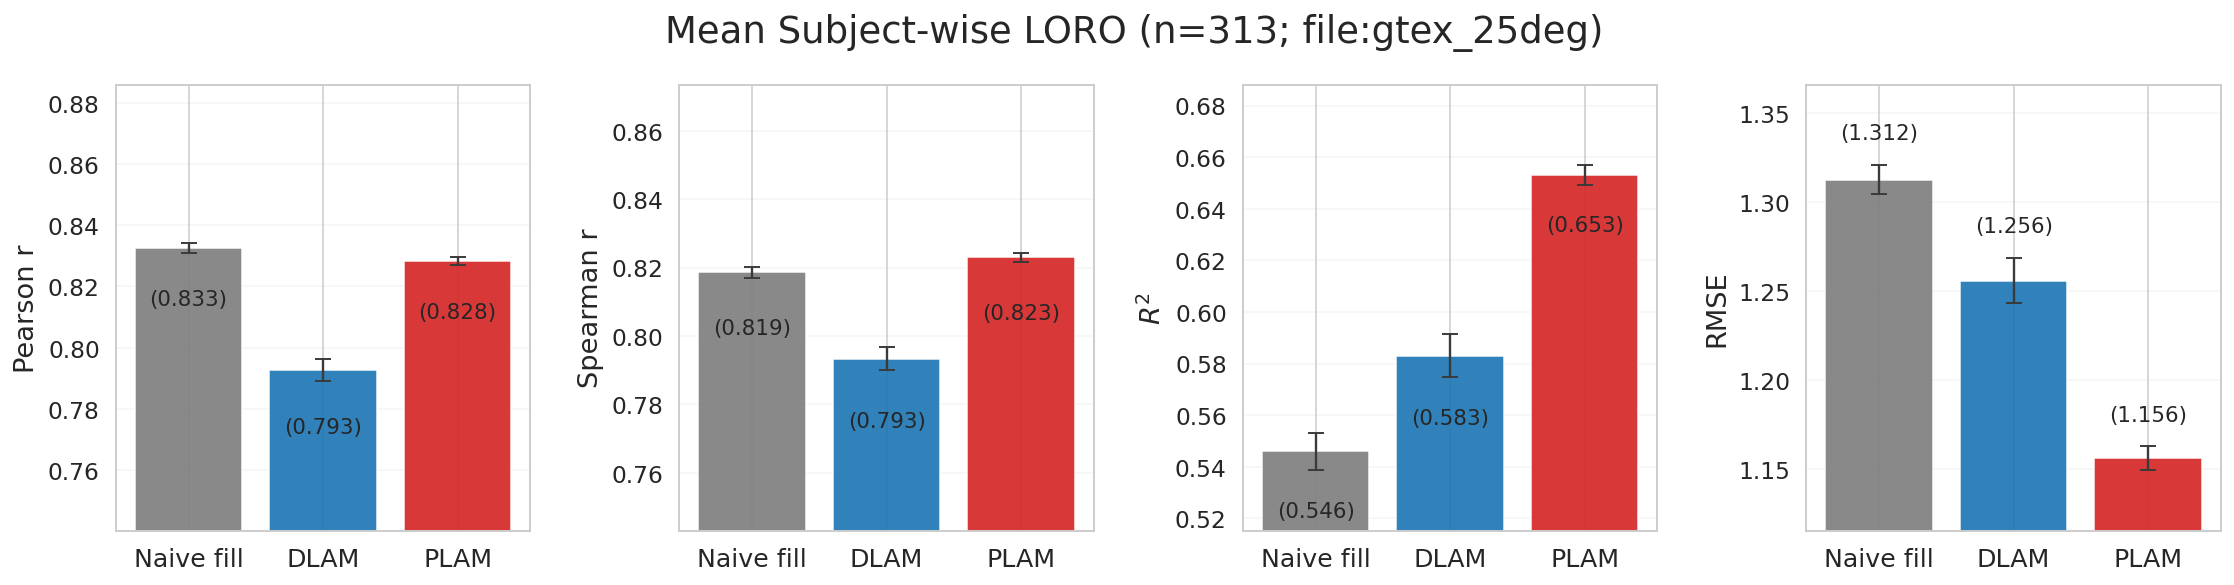

In [19]:
metrics_gtex25deg_eval, summary_gtex25deg_eval, pivot_gtex25deg, t_results_gtex25deg = run_subject_metric_panel(
    label='gtex_25deg',
    eval_gene_path='gtex_25deg',
)

### Richiardi 2015 gene list
Correlated gene expression supports synchronous activity in brain networks (Science, 2015)



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,515,0.781075,0.778728,0.390082,1.357443
1,GTEX-131XW,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,515,0.845739,0.823157,0.433989,1.242877
2,GTEX-13NZA,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,515,0.788484,0.782984,0.406208,1.420084
3,GTEX-1477Z,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,515,0.786855,0.766174,0.371153,1.454818
4,GTEX-17MF6,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,515,0.791047,0.777341,0.377524,1.456552


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.832035,0.026954,0.820764,0.026668,0.595746,0.109245,1.182672,0.123303,313,0.001524,0.001507,0.006175,0.006969
1,dlam,0.827828,0.071262,0.825014,0.059045,0.558194,0.408652,1.184381,0.423704,313,0.004028,0.003337,0.023098,0.023949
2,plam,0.831842,0.049986,0.820442,0.040070,0.637072,0.188930,1.109122,0.246100,313,0.002825,0.002265,0.010679,0.013910



Paired t-tests for richiardi2015:
  dlam vs naive: t = -1.0091, p = 0.3137
  dlam vs plam: t = -2.0083, p = 0.04547
  naive vs plam: t = 0.0648, p = 0.9484


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.789173,0.840220,0.835676
GTEX-111FC,0.795558,0.848552,0.838774
GTEX-117XS,0.820845,0.855044,0.849098
GTEX-1192W,0.855874,0.781075,0.821412
GTEX-1192X,0.845072,0.844201,0.862925


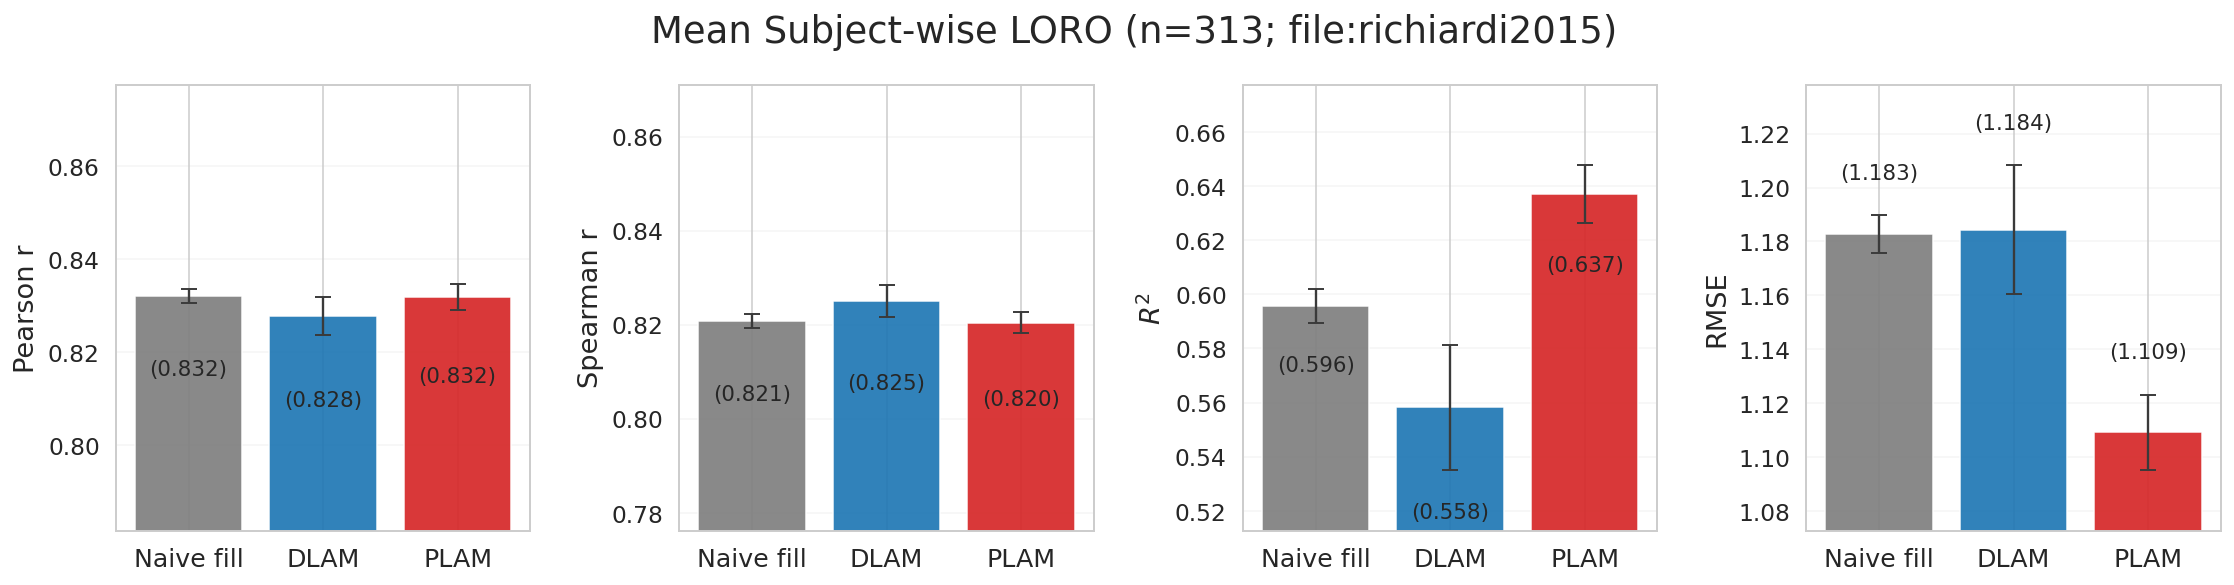

In [20]:
metrics_richiardi_eval, summary_richiardi_eval, pivot_richiardi, t_results_richiardi = run_subject_metric_panel(
    label='richiardi2015',
    eval_gene_path='richiardi2015',
)

### Synaptic gene ontology list



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,7130,0.874057,0.867367,0.627904,1.097044
1,GTEX-131XW,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,7130,0.878686,0.867440,0.602301,1.141272
2,GTEX-13NZA,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,7130,0.853791,0.847507,0.541281,1.240363
3,GTEX-1477Z,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,7130,0.865452,0.858133,0.578763,1.194936
4,GTEX-17MF6,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,None,7130,0.855709,0.843877,0.537914,1.274790


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.897474,0.017515,0.889770,0.017738,0.687126,0.052059,0.973706,0.110401,313,0.000990,0.001003,0.002943,0.006240
1,dlam,0.910060,0.054782,0.918572,0.040161,0.778620,0.238648,0.762046,0.289900,313,0.003096,0.002270,0.013489,0.016386
2,plam,0.905231,0.038879,0.901477,0.033980,0.788335,0.132222,0.777095,0.184181,313,0.002198,0.001921,0.007474,0.010411



Paired t-tests for syngo:
  dlam vs naive: t = 3.8288, p = 0.0001556
  dlam vs plam: t = 3.9055, p = 0.0001153
  naive vs plam: t = -3.1723, p = 0.001663


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.913566,0.915028,0.919289
GTEX-111FC,0.917463,0.909435,0.915063
GTEX-117XS,0.917162,0.912227,0.917311
GTEX-1192W,0.909921,0.874057,0.894633
GTEX-1192X,0.931977,0.903405,0.928879


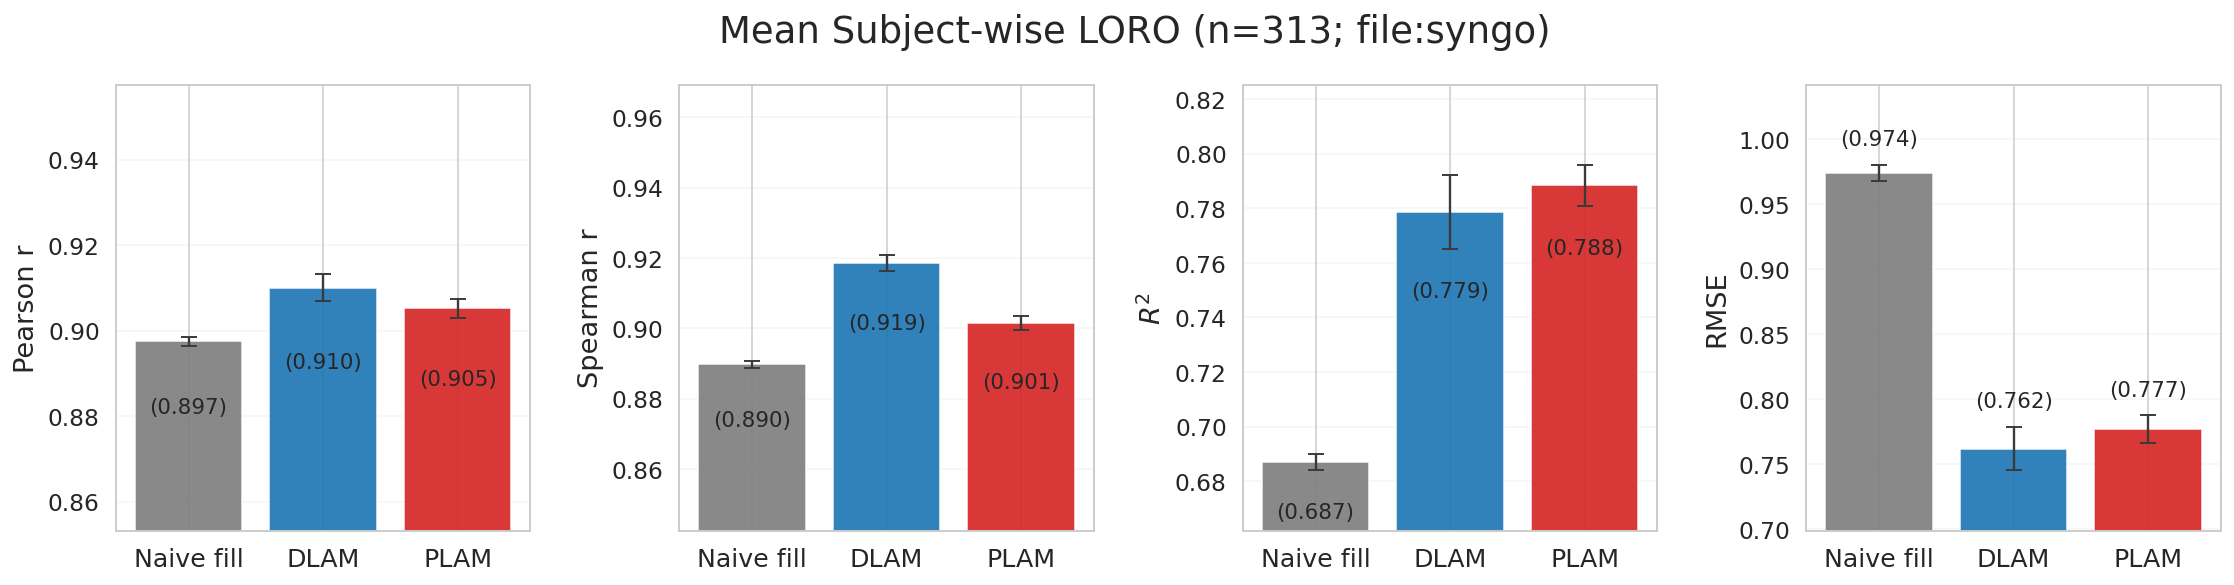

In [21]:
metrics_syngo_eval, summary_syngo_eval, pivot_syngo, t_results_syngo = run_subject_metric_panel(
    label='syngo',
    eval_gene_path='syngo',
)

## 4) Fold-Combo Difficulty



In [22]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG,
    PREPOST,
    coverage_min=5,
    coverage_max=12,
    models=MODELS,
    n_jobs=N_JOBS,
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)
display(combo_df.head())

fold_perf_df: (8460, 16)
combo_df: (4494, 17)


,coverage,fold_key,model,n_subjects,mean_pearson,std_pearson,mean_spearman,std_spearman,mean_r2,std_r2,mean_rmse,std_rmse,mean_points,dist_to_nearest_train,dist_to_centroid_train,eval_gene_mode,eval_gene_path
0,5,"hold=0|train=10,16,31,132",dlam,1,0.777161,NaN,0.805639,NaN,0.461302,NaN,1.148799,NaN,13618.0,52.838640,77.262684,all,None
1,5,"hold=0|train=10,16,31,94",dlam,1,0.884544,NaN,0.893458,NaN,0.774425,NaN,0.791595,NaN,13618.0,37.590386,63.566207,all,None
2,5,"hold=0|train=31,38,55,94",dlam,1,0.869338,NaN,0.884711,NaN,0.747368,NaN,0.852476,NaN,13618.0,34.548075,71.355988,all,None
3,5,"hold=0|train=5,10,29,132",dlam,1,0.891686,NaN,0.918236,NaN,0.766100,NaN,0.757724,NaN,13618.0,21.960420,47.106908,all,None
4,5,"hold=0|train=5,16,31,94",dlam,1,0.963898,NaN,0.968356,NaN,0.885133,NaN,0.579648,NaN,13618.0,21.960420,42.152266,all,None


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,naive,mean_pearson,0.703117,5,1,"hold=94|train=0,5,19,38",94,substantia nigra,"[0, 5, 19, 38]","[cerebellum, cerebellar hemisphere, putamen (b..."
1,median,naive,mean_pearson,0.857812,9,1,"hold=16|train=0,5,18,29,38,55,94,132",16,hypothalamus,"[0, 5, 18, 29, 38, 55, 94, 132]","[cerebellum, cerebellar hemisphere, nucleus ac..."
2,best,naive,mean_pearson,0.930432,10,1,"hold=19|train=0,5,10,16,29,31,55,94,132",19,putamen (basal ganglia),"[0, 5, 10, 16, 29, 31, 55, 94, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,dlam,mean_pearson,0.413361,9,1,"hold=19|train=0,5,16,18,29,38,55,132",19,putamen (basal ganglia),"[0, 5, 16, 18, 29, 38, 55, 132]","[cerebellum, cerebellar hemisphere, hypothalam..."
1,median,dlam,mean_pearson,0.894875,7,1,"hold=94|train=5,10,16,29,31,55",94,substantia nigra,"[5, 10, 16, 29, 31, 55]","[cerebellar hemisphere, caudate (basal ganglia..."
2,best,dlam,mean_pearson,0.982518,10,1,"hold=0|train=5,10,16,18,19,29,38,55,94",0,cerebellum,"[5, 10, 16, 18, 19, 29, 38, 55, 94]","[cerebellar hemisphere, caudate (basal ganglia..."


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,plam,mean_pearson,0.479461,9,1,"hold=19|train=0,5,16,18,29,38,55,132",19,putamen (basal ganglia),"[0, 5, 16, 18, 29, 38, 55, 132]","[cerebellum, cerebellar hemisphere, hypothalam..."
1,median,plam,mean_pearson,0.881925,8,1,"hold=0|train=5,10,16,31,55,94,132",0,cerebellum,"[5, 10, 16, 31, 55, 94, 132]","[cerebellar hemisphere, caudate (basal ganglia..."
2,best,plam,mean_pearson,0.970659,6,1,"hold=29|train=10,18,55,94,132",29,amygdala,"[10, 18, 55, 94, 132]","[caudate (basal ganglia), nucleus accumbens (b..."


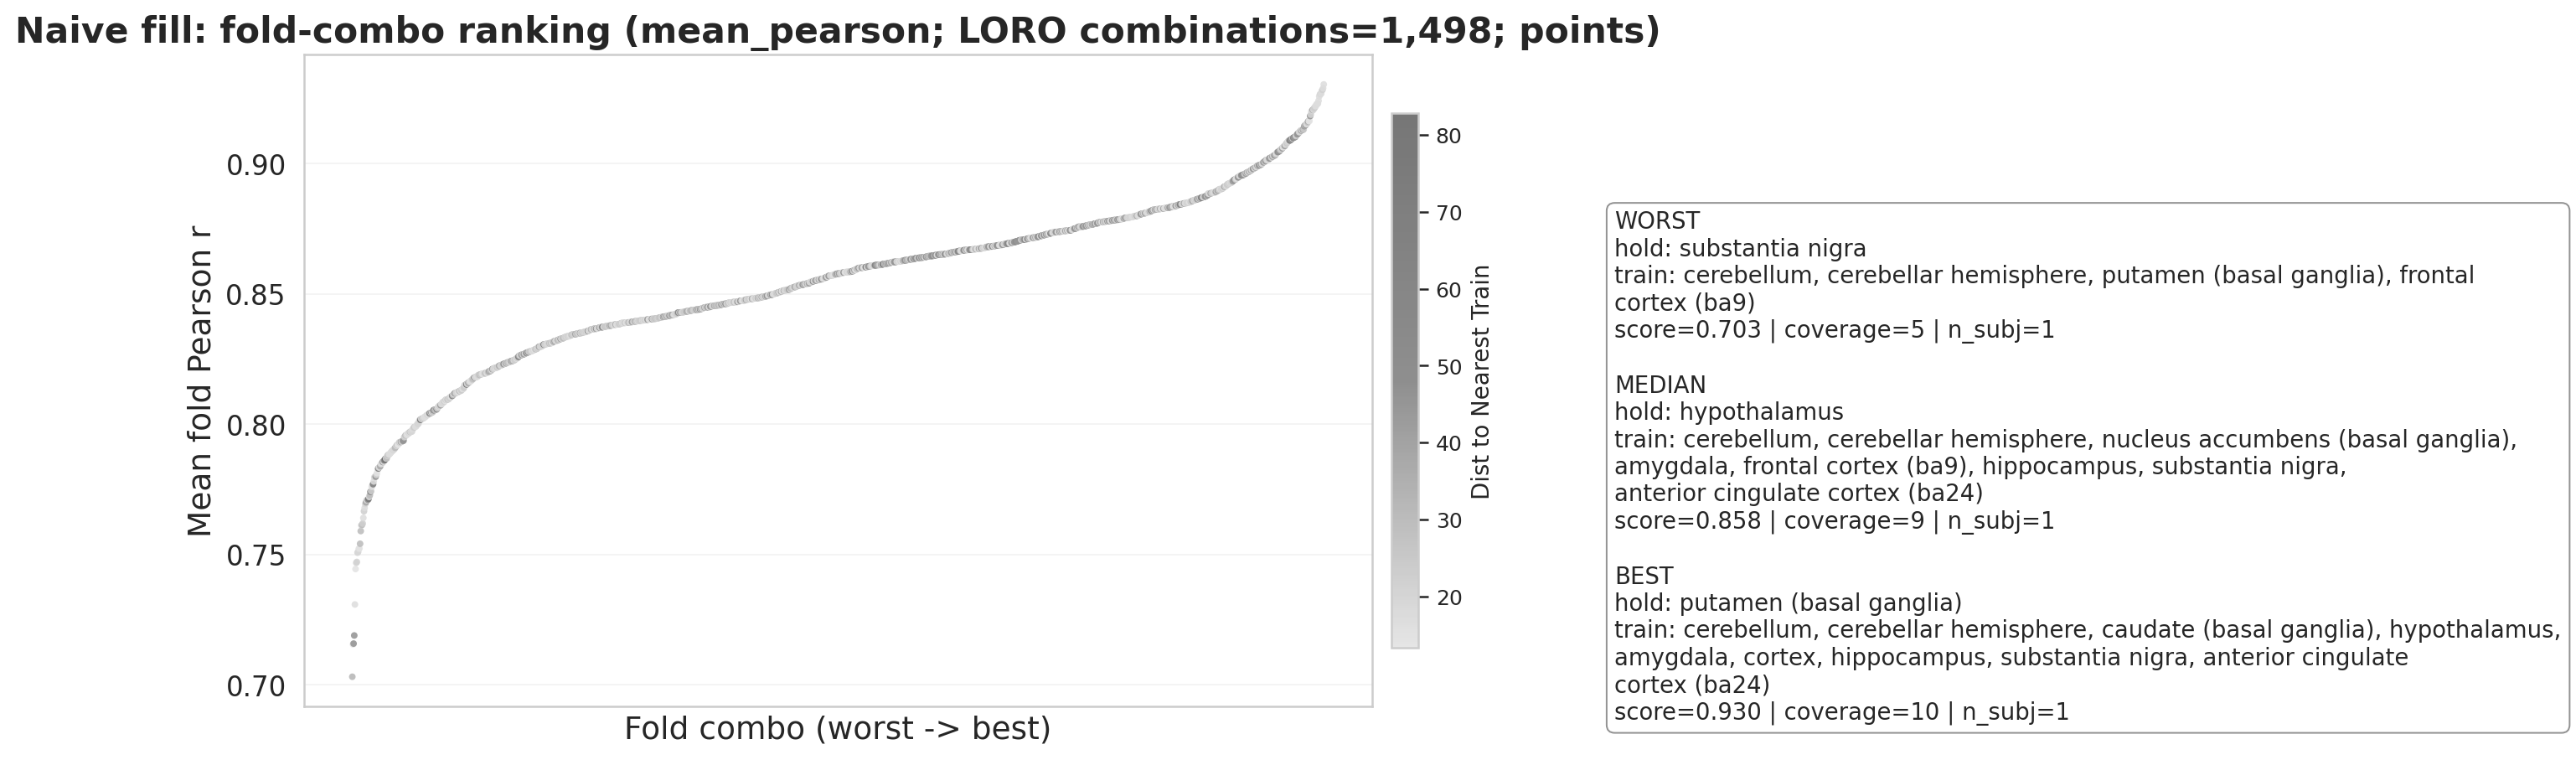

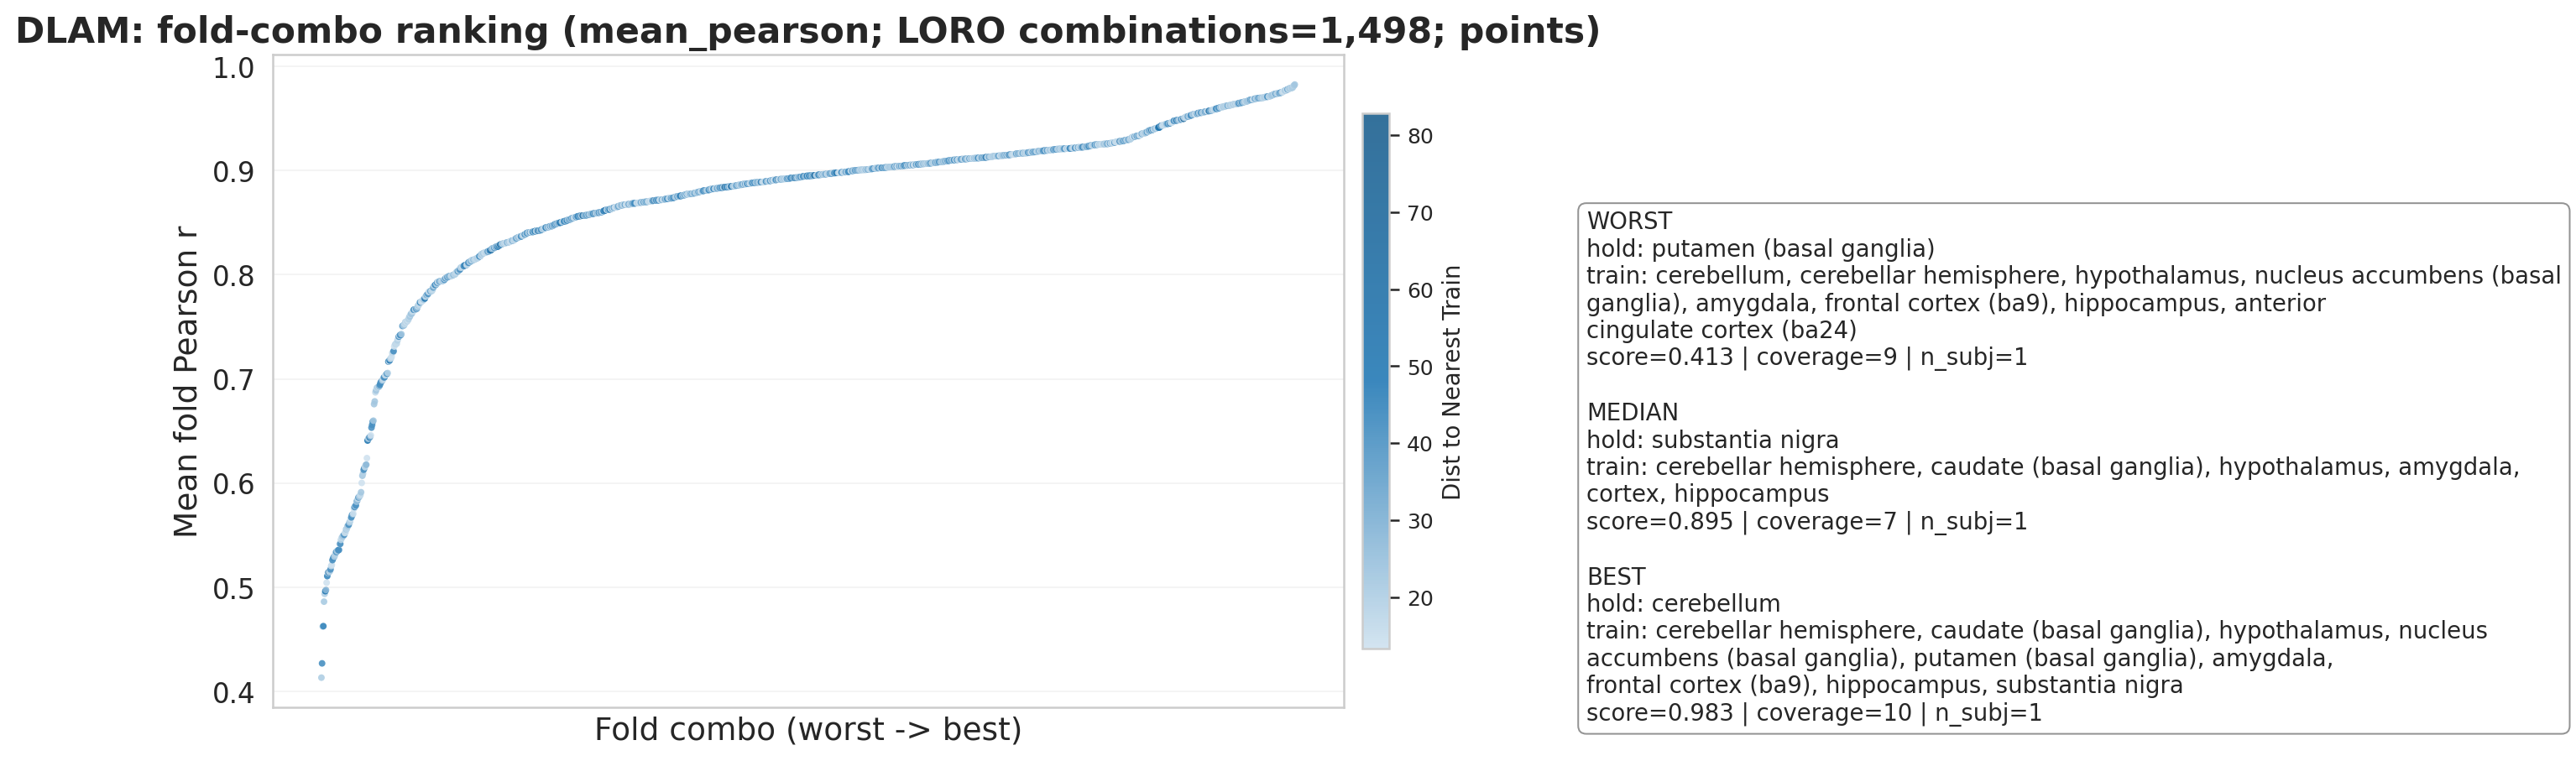

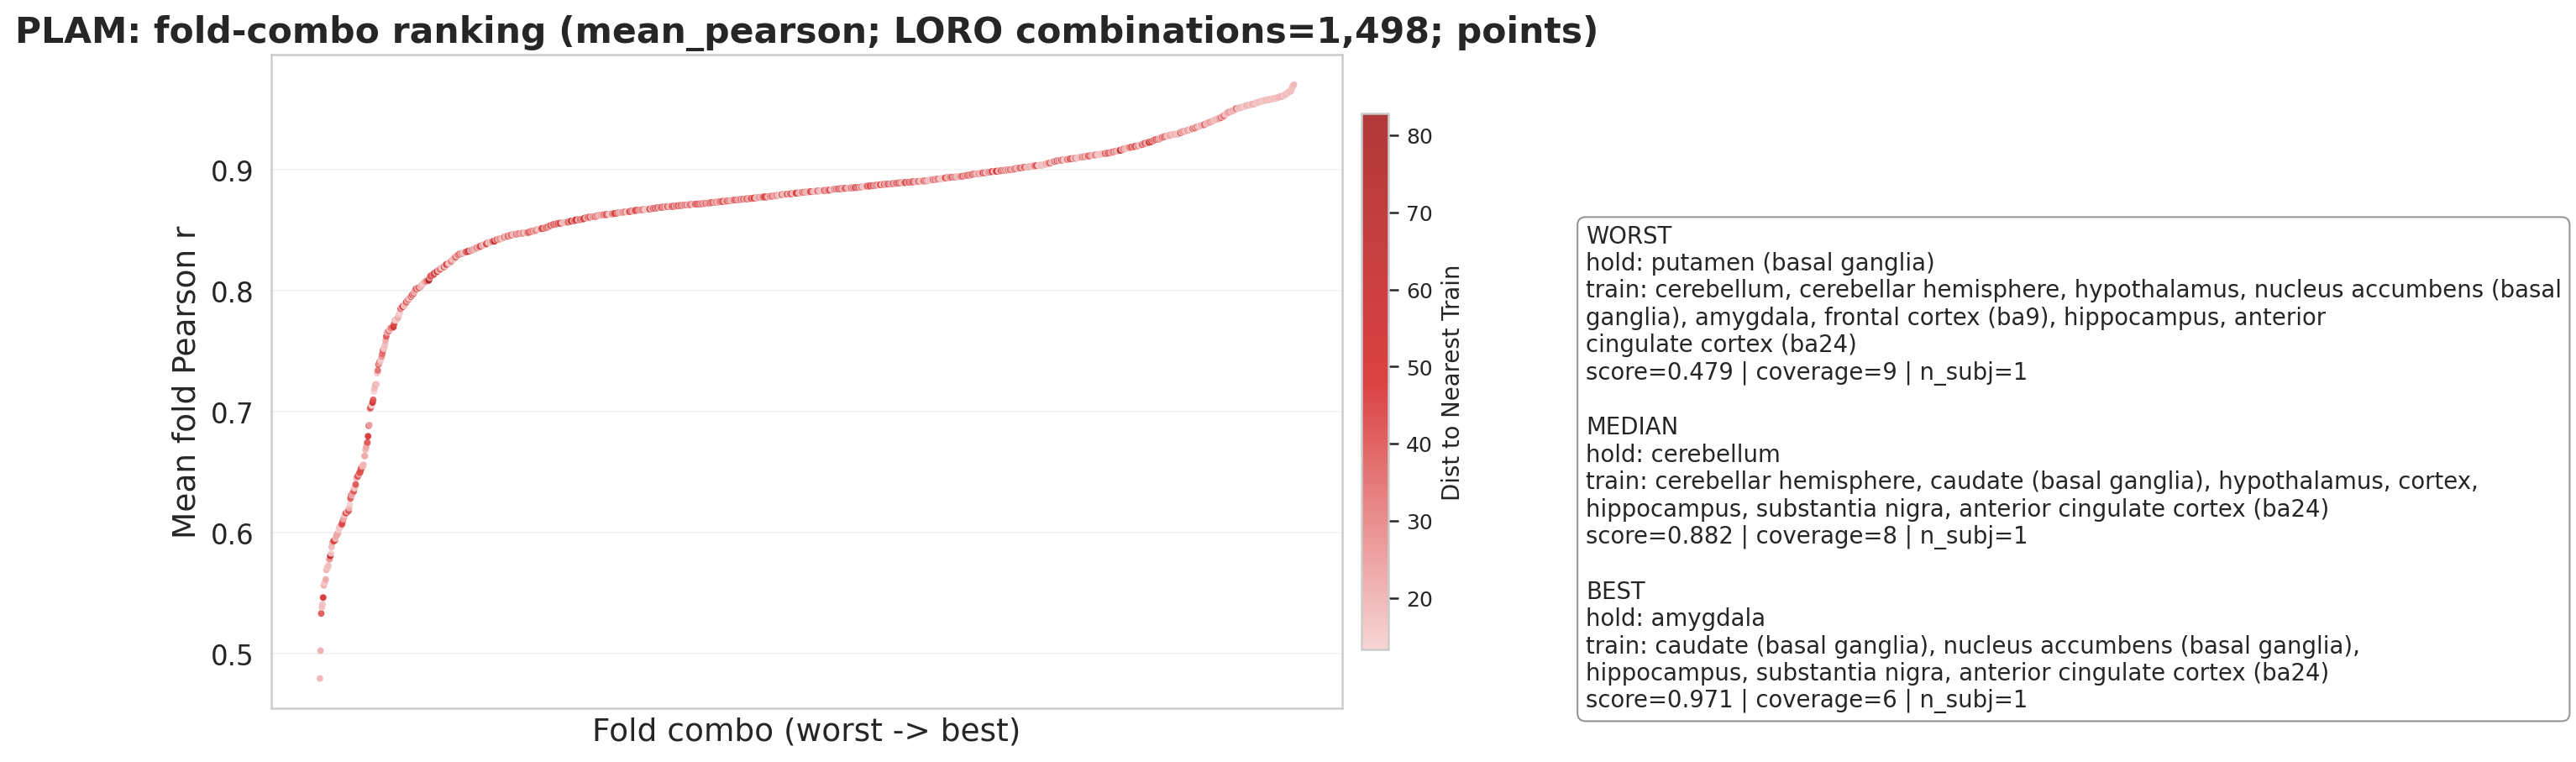

In [23]:
for model_name in MODELS:
    fig, ax, key_table = plot_fold_combo_ranked(
        combo_df,
        PREPOST,
        model=model_name,
        metric='mean_pearson',
        style='points',
        points_style='dist_to_nearest_train',
        show_running_average=False,
        running_average_window=20,
    )
    display(key_table)

,hold_parcel,model,n_subjects,n_folds,mean_pearson,std_pearson,mean_spearman,std_spearman,mean_r2,std_r2,mean_rmse,std_rmse,gtex_label,ahba_label,label
0,0,dlam,247,247,0.883853,0.096603,0.919195,0.057945,0.544423,0.799508,0.930653,0.632158,cerebellum,Cerebellar_Region1,cerebellum
1,0,naive,247,247,0.846098,0.021762,0.887098,0.012867,0.594095,0.051676,1.057578,0.093592,cerebellum,Cerebellar_Region1,cerebellum
2,0,plam,247,247,0.857137,0.079040,0.880272,0.051802,0.664142,0.265705,0.913702,0.302922,cerebellum,Cerebellar_Region1,cerebellum
3,5,dlam,258,258,0.876141,0.105785,0.911075,0.065946,0.548630,0.788768,0.945995,0.625751,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
4,5,naive,258,258,0.846171,0.025137,0.888237,0.022758,0.651903,0.058065,0.994843,0.104970,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
5,5,plam,258,258,0.849605,0.087033,0.871994,0.058055,0.662828,0.264960,0.932281,0.300461,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
6,10,dlam,274,274,0.882207,0.098445,0.916295,0.061259,0.578853,0.727902,0.923188,0.583256,caudate (basal ganglia),LH-Ca,caudate (basal ganglia)
7,10,naive,274,274,0.871423,0.028940,0.911515,0.028654,0.647282,0.068053,1.002789,0.126669,caudate (basal ganglia),LH-Ca,caudate (basal ganglia)
8,10,plam,274,274,0.890908,0.077834,0.920273,0.053485,0.751312,0.227361,0.788252,0.295193,caudate (basal ganglia),LH-Ca,caudate (basal ganglia)
9,16,dlam,238,238,0.864680,0.095464,0.895068,0.059211,0.558074,0.684736,0.971155,0.534439,hypothalamus,LH-HTH,hypothalamus


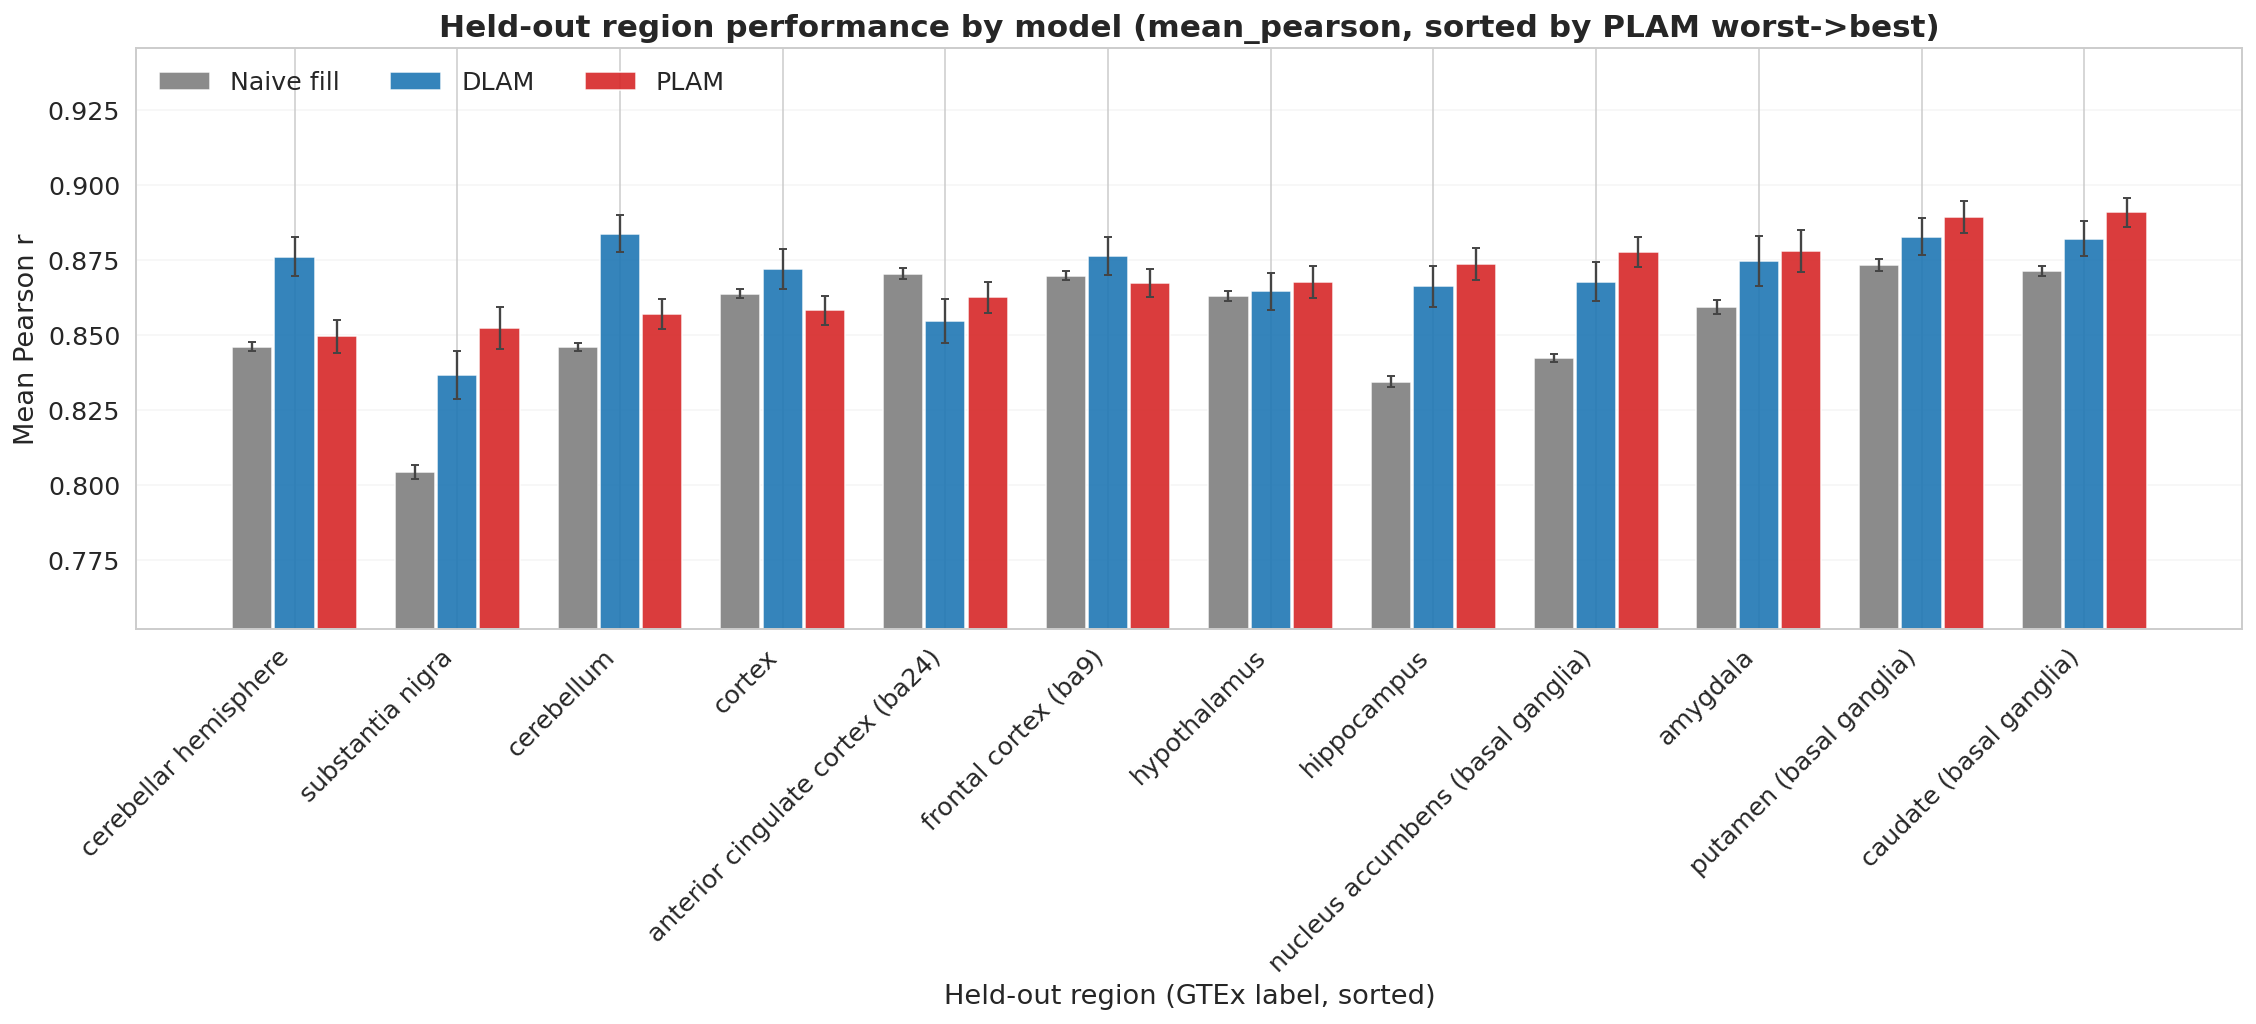

In [24]:
heldout_df = summarize_heldout_region_performance(fold_perf_df, PREPOST)
fig, ax, heldout_plot_df = plot_heldout_region_grouped_bars(
    heldout_df,
    metric='mean_pearson',
    sort_by_model='plam',
    use_error_bars=True,
    error_kind='sem',
)
display(heldout_df.head(20))